# LEG phase estimation for quadrupeds

In [40]:
# First, we will import all the needed libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### Import the data and specify the needed columns


In [41]:
#First, I will import the data that is saved in a CSV file
df = pd.read_csv(r"C:\Users\USAID\Desktop\final.csv")

#The file contains a lot of sensor measurements, so here I am just specifying the columns that are relevant to me and will be used as inputs and outputs

#There are four legs: Front right, Front left, Rear right, Rear left. Each one contains 3 joints. Thus, 12 torque measurements
torque_cols = ["FR_t0", "FR_t1","FR_t2","FL_t0", "FL_t1", "FL_t2", "RR_t0", "RR_t1","RR_t2", "RL_t0", "RL_t1","RL_t2"]

#For the output: there are four columns for the four legs with a binary value; 1 for leg in contact with the ground and 0 otherwise
label_cols = ["FR","FL","RR","RL"]

X = df[torque_cols]
y = df[label_cols]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3124, 12)
y shape: (3124, 4)


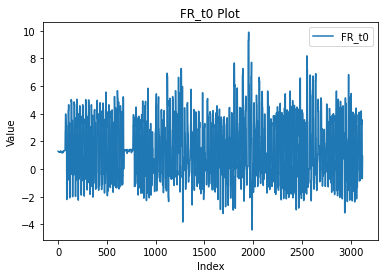

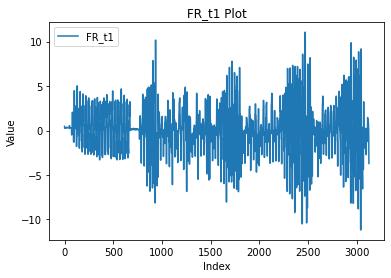

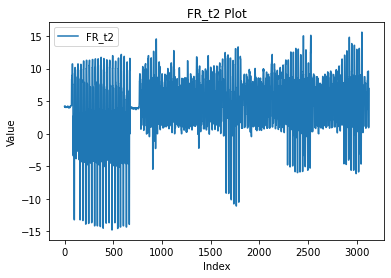

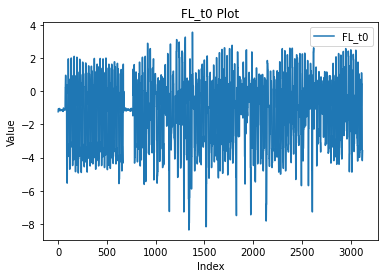

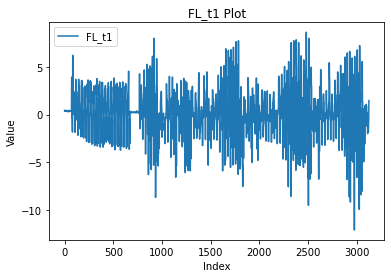

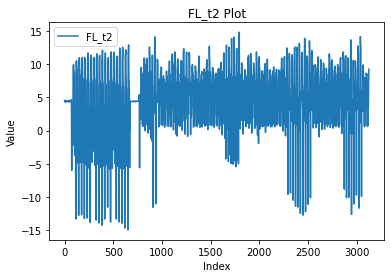

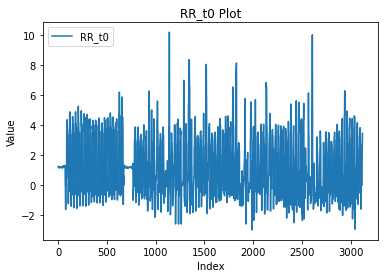

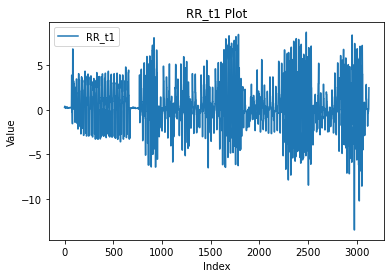

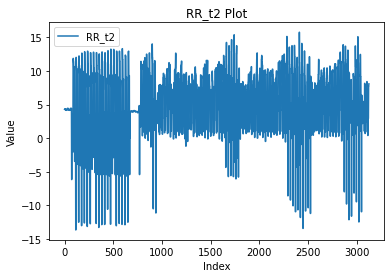

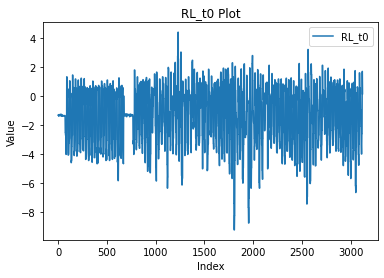

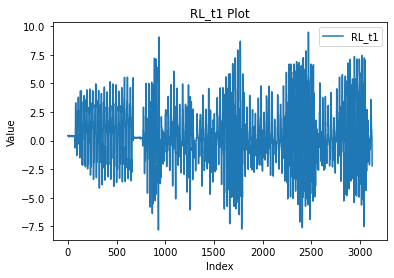

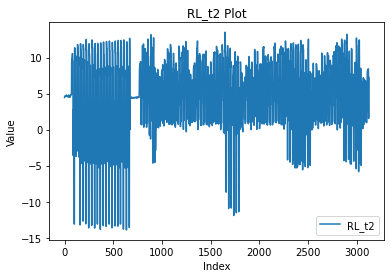

In [42]:
for column in torque_cols:
    plt.figure() 
    plt.plot(df[column], label=column)
    plt.title(f'{column} Plot') 
    plt.xlabel('Index') 
    plt.ylabel('Value') 
    plt.legend() 
    plt.show() 

### Splitting the data

In [43]:
#I am splitting the data into testing (20 %), and the rest I will re-split into train and validation
X_train_val, X_test, y_train_val, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

#Spliting the rest into train and validation
X_train, X_val, y_train, y_val = train_test_split( X_train_val, y_train_val, test_size=0.2, random_state=42)


### Building and Training a multi-output random forest 

In [44]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
model = MultiOutputClassifier(rf_base)

# Train on the training set
model.fit(X_train, y_train)

MultiOutputClassifier(estimator=RandomForestClassifier(random_state=42))

In [45]:
print("\nValidation Results:")
y_val_pred = model.predict(X_val)

#Accuracy of each leg on validation set
for i, leg_col in enumerate(label_cols):
    leg_acc = accuracy_score(y_val.iloc[:, i], y_val_pred[:, i])
    print(f"{leg_col} (Validation): {leg_acc:.3f}")


Validation Results:
FR (Validation): 0.996
FL (Validation): 0.998
RR (Validation): 0.996
RL (Validation): 0.996


### Results 

In [46]:
print("\nTest Results:")
y_test_pred = model.predict(X_test)

# Per-leg accuracy on test set
print("\nModel accuracy for each leg:")
for i, leg_col in enumerate(label_cols):
    leg_acc = accuracy_score(y_test.iloc[:, i], y_test_pred[:, i])
    print(f"{leg_col} (Test): {leg_acc:.3f}")

# Classification report per each leg
for i, leg_col in enumerate(label_cols):
    print(f"\nClassification Report for {leg_col} (Test):")
    print(classification_report(y_test.iloc[:, i], y_test_pred[:, i]))





Test Results:

Model accuracy for each leg:
FR (Test): 0.997
FL (Test): 0.995
RR (Test): 0.998
RL (Test): 1.000

Classification Report for FR (Test):
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       265
           1       1.00      0.99      1.00       360

    accuracy                           1.00       625
   macro avg       1.00      1.00      1.00       625
weighted avg       1.00      1.00      1.00       625


Classification Report for FL (Test):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       247
           1       1.00      0.99      1.00       378

    accuracy                           1.00       625
   macro avg       0.99      1.00      0.99       625
weighted avg       1.00      1.00      1.00       625


Classification Report for RR (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       262
          

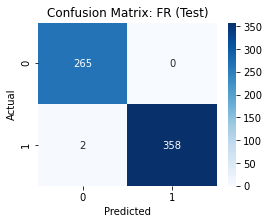

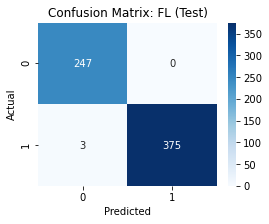

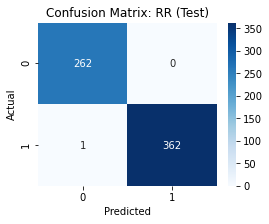

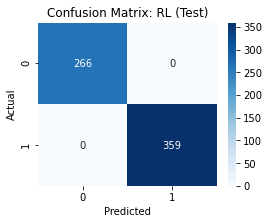

In [47]:
# Confusion matrices for each leg
for i, leg_col in enumerate(label_cols):
    cm = confusion_matrix(y_test.iloc[:, i], y_test_pred[:, i])
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {leg_col} (Test)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()